In [1]:
import re
import pandas as pd


def parse_can_log(path):
    """
    Parse CAN log lines like:
    (1290000000.012715) can0 230#FD000002D4000400
    Returns a DataFrame with columns: Timestamp (float), ID (hex str), Data (hex str), ID_int (int)
    """
    pattern = re.compile(r'^\((?P<ts>\d+\.\d+)\)\s+\S+\s+(?P<id>[0-9A-Fa-f]+)#(?P<data>[0-9A-Fa-f]+)')
    rows = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            m = pattern.match(line.strip())
            if not m:
                continue
            ts = float(m.group('ts'))
            id_hex = m.group('id').upper()
            data_hex = m.group('data').upper()
            try:
                id_int = int(id_hex, 16)
            except ValueError:
                id_int = None
            rows.append((ts, id_hex, data_hex, id_int))
    return pd.DataFrame(rows, columns=['Timestamp', 'ID', 'Data', 'ID_int'])

In [2]:
import os
import json
import pandas as pd

# Load metadata
with open(r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\datasets\road_dataset\road\attacks\capture_metadata.json", "r") as f:
    metadata = json.load(f)


def matches_pattern(data, pattern):
    """Compare a CAN payload against a pattern (X = wildcard)."""
    data = str(data).upper()
    pattern = pattern.upper()

    if len(data) != len(pattern):
        return False

    return all(p == "X" or d == p for d, p in zip(data, pattern))


def load_attack(log_name):

    path = os.path.join(
        r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks",
        "datasets",
        "road_dataset",
        "road",
        "attacks",
        log_name + ".log"
    )

    df = parse_can_log(path)

    # Default label
    df["Attack"] = "R"

    info = metadata.get(log_name)

    # If no injection metadata exists (e.g. accelerator attacks)
    if (
        info is None
        or info["injection_interval"] is None
        or info["injection_id"] is None
        or info["injection_data_str"] is None
    ):
        return df, False

    base_timestamp = df["Timestamp"].iloc[0]
    start, end = info["injection_interval"]

    attack_id = info["injection_id"].lower()
    pattern = info["injection_data_str"]    

    df["ID"] = df["ID"].astype(str).str.lower()
    df["Data"] = df["Data"].astype(str).str.upper()

    # Label only injected packets during the recorded interval
    if attack_id != "xxx":
        relative_ts = df["Timestamp"] - base_timestamp
        attack_mask = (
            (df["ID_int"] == int(attack_id, 16)) &
            (df["Data"].apply(lambda x: matches_pattern(x, pattern))) &
            (relative_ts >= start) &
            (relative_ts <= end)
        )
    else:
        return 0, False

    df.loc[attack_mask, "Attack"] = "T"

    return df, True

In [3]:
import os

def load_ambient(log_name):
    """
    Load a ROAD ambient log.
    All packets are labelled as Regular ('R').
    """

    path = os.path.join(
        r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks",
        "datasets",
        "road_dataset",
        "road",
        "ambient",
        log_name + ".log"
    )

    # Load log
    df = parse_can_log(path)

    # All packets are normal
    df["Attack"] = "R"

    return df

In [4]:
AMBIENT_FOLDER = (
    r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks"
    r"\datasets\road_dataset\road\ambient"
)

ambient_dfs = {}

for filename in os.listdir(AMBIENT_FOLDER):

    if not filename.endswith(".log"):
        continue

    log_name = filename[:-4]  # Remove ".log"

    print(f"Loading {log_name}...")

    ambient_dfs[log_name] = load_ambient(log_name)

print(f"\nLoaded {len(ambient_dfs)} ambient datasets.")

Loading ambient_dyno_drive_basic_long...
Loading ambient_dyno_drive_basic_short...
Loading ambient_dyno_drive_benign_anomaly...
Loading ambient_dyno_drive_extended_long...
Loading ambient_dyno_drive_extended_short...
Loading ambient_dyno_drive_radio_infotainment...
Loading ambient_dyno_drive_winter...
Loading ambient_dyno_exercise_all_bits...
Loading ambient_dyno_idle_radio_infotainment...
Loading ambient_dyno_reverse...
Loading ambient_highway_street_driving_diagnostics...
Loading ambient_highway_street_driving_long...

Loaded 12 ambient datasets.


In [5]:
import os

ATTACK_FOLDER = (
    r"C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks"
    r"\datasets\road_dataset\road\attacks"
)

# Dictionary of all attack DataFrames
attack_dfs = {}

for filename in os.listdir(ATTACK_FOLDER):

    # Only load .log files
    if not filename.endswith(".log"):
        continue

    attack_name = filename[:-4]  # Remove ".log"

    print(f"Loading {attack_name}...")

    df, valid = load_attack(attack_name)
    if valid:
        attack_dfs[attack_name] = df

print(f"\nLoaded {len(attack_dfs)} attack datasets.")

Loading accelerator_attack_drive_1...
Loading accelerator_attack_drive_2...
Loading accelerator_attack_reverse_1...
Loading accelerator_attack_reverse_2...
Loading correlated_signal_attack_1...
Loading correlated_signal_attack_1_masquerade...
Loading correlated_signal_attack_2...
Loading correlated_signal_attack_2_masquerade...
Loading correlated_signal_attack_3...
Loading correlated_signal_attack_3_masquerade...
Loading fuzzing_attack_1...
Loading fuzzing_attack_2...
Loading fuzzing_attack_3...
Loading max_engine_coolant_temp_attack...
Loading max_engine_coolant_temp_attack_masquerade...
Loading max_speedometer_attack_1...
Loading max_speedometer_attack_1_masquerade...
Loading max_speedometer_attack_2...
Loading max_speedometer_attack_2_masquerade...
Loading max_speedometer_attack_3...
Loading max_speedometer_attack_3_masquerade...
Loading reverse_light_off_attack_1...
Loading reverse_light_off_attack_1_masquerade...
Loading reverse_light_off_attack_2...
Loading reverse_light_off_atta

In [6]:
import numpy as np

def convert_to_array(df, attack_label='T'):
    ids = df['ID'].to_numpy(dtype=object)
    data = df['Data'].to_numpy(dtype=object)
    attack = df['Attack'].to_numpy(dtype=object)

    samples = np.column_stack((ids, data))
    labels = np.where(attack == 'T', attack_label, 'R').astype(object)

    return samples, labels


In [7]:
def _hex_byte_list_from_row(row):
    if isinstance(row, np.ndarray):
        row = row.tolist()

    if isinstance(row, (list, tuple)):
        if len(row) == 2:
            msg_id, data = row
        elif len(row) == 0:
            raise ValueError("Encountered an empty row")
        else:
            msg_id, data = row[0], row[1]
    else:
        raise ValueError(f"Expected a row-like value, got: {row}")

    msg_id = str(msg_id).strip()
    if len(msg_id) % 2 != 0:
        msg_id = '0' + msg_id

    id_bytes = [int(msg_id[i:i+2], 16) for i in range(0, len(msg_id), 2)]
    data_bytes = []
    for item in str(data).split():
        if not item:
            continue
        try:
            data_bytes.append(int(item, 16))
        except ValueError:
            data_bytes.append(int(item))

    return id_bytes + data_bytes


def convert_windowed_id_data_to_ints(windowed_data, pad_value=0):
    int_windows = []
    for window in windowed_data:
        if isinstance(window, np.ndarray):
            window = window.tolist()

        rows = []
        for row in window:
            rows.append(_hex_byte_list_from_row(row))

        max_len = max(len(r) for r in rows)
        padded_rows = [r + [pad_value] * (max_len - len(r)) for r in rows]
        int_windows.append(padded_rows)
    return int_windows

def format_id_data_windows(windows):
    formatted_all = []
    for window in windows:
        window = np.asarray(window, dtype=object)
        formatted = []
        for msg_id, data in window:
            id_str = str(msg_id).strip().lower().zfill(4)
            data_str = str(data).strip().lower()
            data_str = re.sub(r'[^0-9a-f]', '', data_str)
            if len(data_str) % 2:
                data_str = '0' + data_str
            data_bytes = [data_str[i:i+2] for i in range(0, len(data_str), 2)] if data_str else []
            formatted.append([id_str, ' '.join(data_bytes)])
        formatted_all.append(np.array(formatted, dtype=object))
    return np.array(formatted_all, dtype=object)

In [8]:
attack_train_dfs = {}
attack_test_dfs = {}



for name, df in attack_dfs.items():
    split = int(len(df) * 0.2)

    # Split
    df_test = df.iloc[:split].reset_index(drop=True).copy()
    df_train = df.iloc[split:].reset_index(drop=True).copy()


    # Store dataframes
    attack_train_dfs[name] = df_train
    attack_test_dfs[name] = df_test

In [22]:
import itertools

ambient_train_dfs = {}
ambient_test_dfs = {}


for name, df in itertools.islice(ambient_dfs.items(), 2):
    split = int(len(df) * 0.2)

    df_test = df.iloc[:split].reset_index(drop=True).copy()
    df_train = df.iloc[split:].reset_index(drop=True).copy()

    ambient_train_dfs[name] = df_train
    ambient_test_dfs[name] = df_test


    print(name)

ambient_dyno_drive_basic_long
ambient_dyno_drive_basic_short


In [23]:

# Save train and test dataframes as lists
train_dfs_list = list(attack_train_dfs.values()) + list(ambient_train_dfs.values())
test_dfs_list = list(attack_test_dfs.values()) + list(ambient_test_dfs.values())

In [28]:
# Build stable ID vocabulary from the training data
train_unique_ids = set()
for df in train_dfs_list:
    train_unique_ids.update(df["ID"].astype(str).str.strip().str.lower())

ids = [str(x).strip().lower() for x in train_unique_ids]
id_vocab = list(dict.fromkeys(ids))
id_to_idx = {iid: i for i, iid in enumerate(id_vocab)}

if len(id_vocab) > 170:
    raise ValueError(f"Too many IDs ({len(id_vocab)}) for a 10x17 matrix.")

def add_id_onehot_column(df, id_to_idx):
    df = df.copy()

    ids = df["ID"].astype(str).str.strip().str.lower()

    # Create one-hot vectors of length 176
    onehot = np.zeros((len(df), 176), dtype=np.uint8)

    valid = ids.isin(id_to_idx)

    if valid.any():
        rows = np.flatnonzero(valid)
        cols = ids[valid].map(id_to_idx).to_numpy(dtype=int)
        onehot[rows, cols] = 1

    # Reshape each vector into a 22x8 matrix
    df["ID_onehot"] = [mat.reshape(22, 8) for mat in onehot]

    return df

# Apply to all dataframes
train_dfs_list = [add_id_onehot_column(df, id_to_idx) for df in train_dfs_list]
test_dfs_list = [add_id_onehot_column(df, id_to_idx) for df in test_dfs_list]

print("Added ID_onehot column with 22x8 matrices.")

Added ID_onehot column with 22x8 matrices.


In [29]:
def rescale_id_onehot(df):
    df = df.copy()
    df["ID_onehot"] = [
        np.where(np.asarray(mat, dtype=np.int16) == 0, 0, np.asarray(mat, dtype=np.int16) * 8 - 1)
        for mat in df["ID_onehot"]
    ]
    return df

train_dfs_list = [rescale_id_onehot(df) for df in train_dfs_list]
test_dfs_list = [rescale_id_onehot(df) for df in test_dfs_list]

In [30]:
print(test_dfs_list[0][["ID", "ID_onehot"]])

        ID                                          ID_onehot
0      354  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
1      5e1  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
2      28b  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
3      0a7  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
4      0d0  [[0, 0, 7, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
...    ...                                                ...
16247  6e0  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
16248  498  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
16249  230  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
16250  2e1  [[0, 7, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...
16251  354  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...

[16252 rows x 2 columns]


In [31]:
import pickle
# Save to files

with open("saved_data/ROAD/train_dfs.pkl", "wb") as f:
    pickle.dump(train_dfs_list, f)

with open("saved_data/ROAD/test_dfs.pkl", "wb") as f:
    pickle.dump(test_dfs_list, f)

print(f"Saved {len(train_dfs_list)} training dataframes")
print(f"Saved {len(test_dfs_list)} test dataframes")

Saved 28 training dataframes
Saved 28 test dataframes


In [32]:
print(test_dfs_list[0]["ID_onehot"][100])

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 7 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [33]:
print(train_dfs_list[0].head())

      Timestamp   ID              Data  ID_int Attack  \
0  1.030000e+09  153  00000000000C000A     339      R   
1  1.030000e+09  5e1  892F600B0A010080    1505      R   
2  1.030000e+09  662  4EE0000040000000    1634      R   
3  1.030000e+09  19c  007E2010020028F0     412      R   
4  1.030000e+09  0d0  027704605F039A00     208      R   

                                           ID_onehot  
0  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...  
1  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...  
2  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...  
3  [[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...  
4  [[0, 0, 7, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...  


In [34]:
# Training data
int_id_data = []
attack_labels = []

for df in train_dfs_list:
    data, labels = convert_to_array(df)
    int_id_data.append(data)
    attack_labels.append(labels)

# Test data
int_id_data_test = []
attack_labels_test = []

for df in test_dfs_list:
    data, labels = convert_to_array(df)
    int_id_data_test.append(data)
    attack_labels_test.append(labels)

In [35]:
# Format ID data
int_id_data = format_id_data_windows(int_id_data)
int_id_data_test = format_id_data_windows(int_id_data_test)

# Convert IDs to integers
int_id_data = convert_windowed_id_data_to_ints(int_id_data)
int_id_data_test = convert_windowed_id_data_to_ints(int_id_data_test)

# Convert each dataset to a NumPy array
int_id_data = [np.array(arr) for arr in int_id_data]
int_id_data_test = [np.array(arr) for arr in int_id_data_test]

In [36]:
import numpy as np

# Save training data
np.save("saved_data/ROAD/int_id_data.npy", np.array(int_id_data, dtype=object))
np.save("saved_data/ROAD/attack_labels.npy", np.array(attack_labels, dtype=object))

# Save test data
np.save("saved_data/ROAD/int_id_data_test.npy", np.array(int_id_data_test, dtype=object))
np.save("saved_data/ROAD/attack_labels_test.npy", np.array(attack_labels_test, dtype=object))

print("Arrays saved successfully.")

Arrays saved successfully.


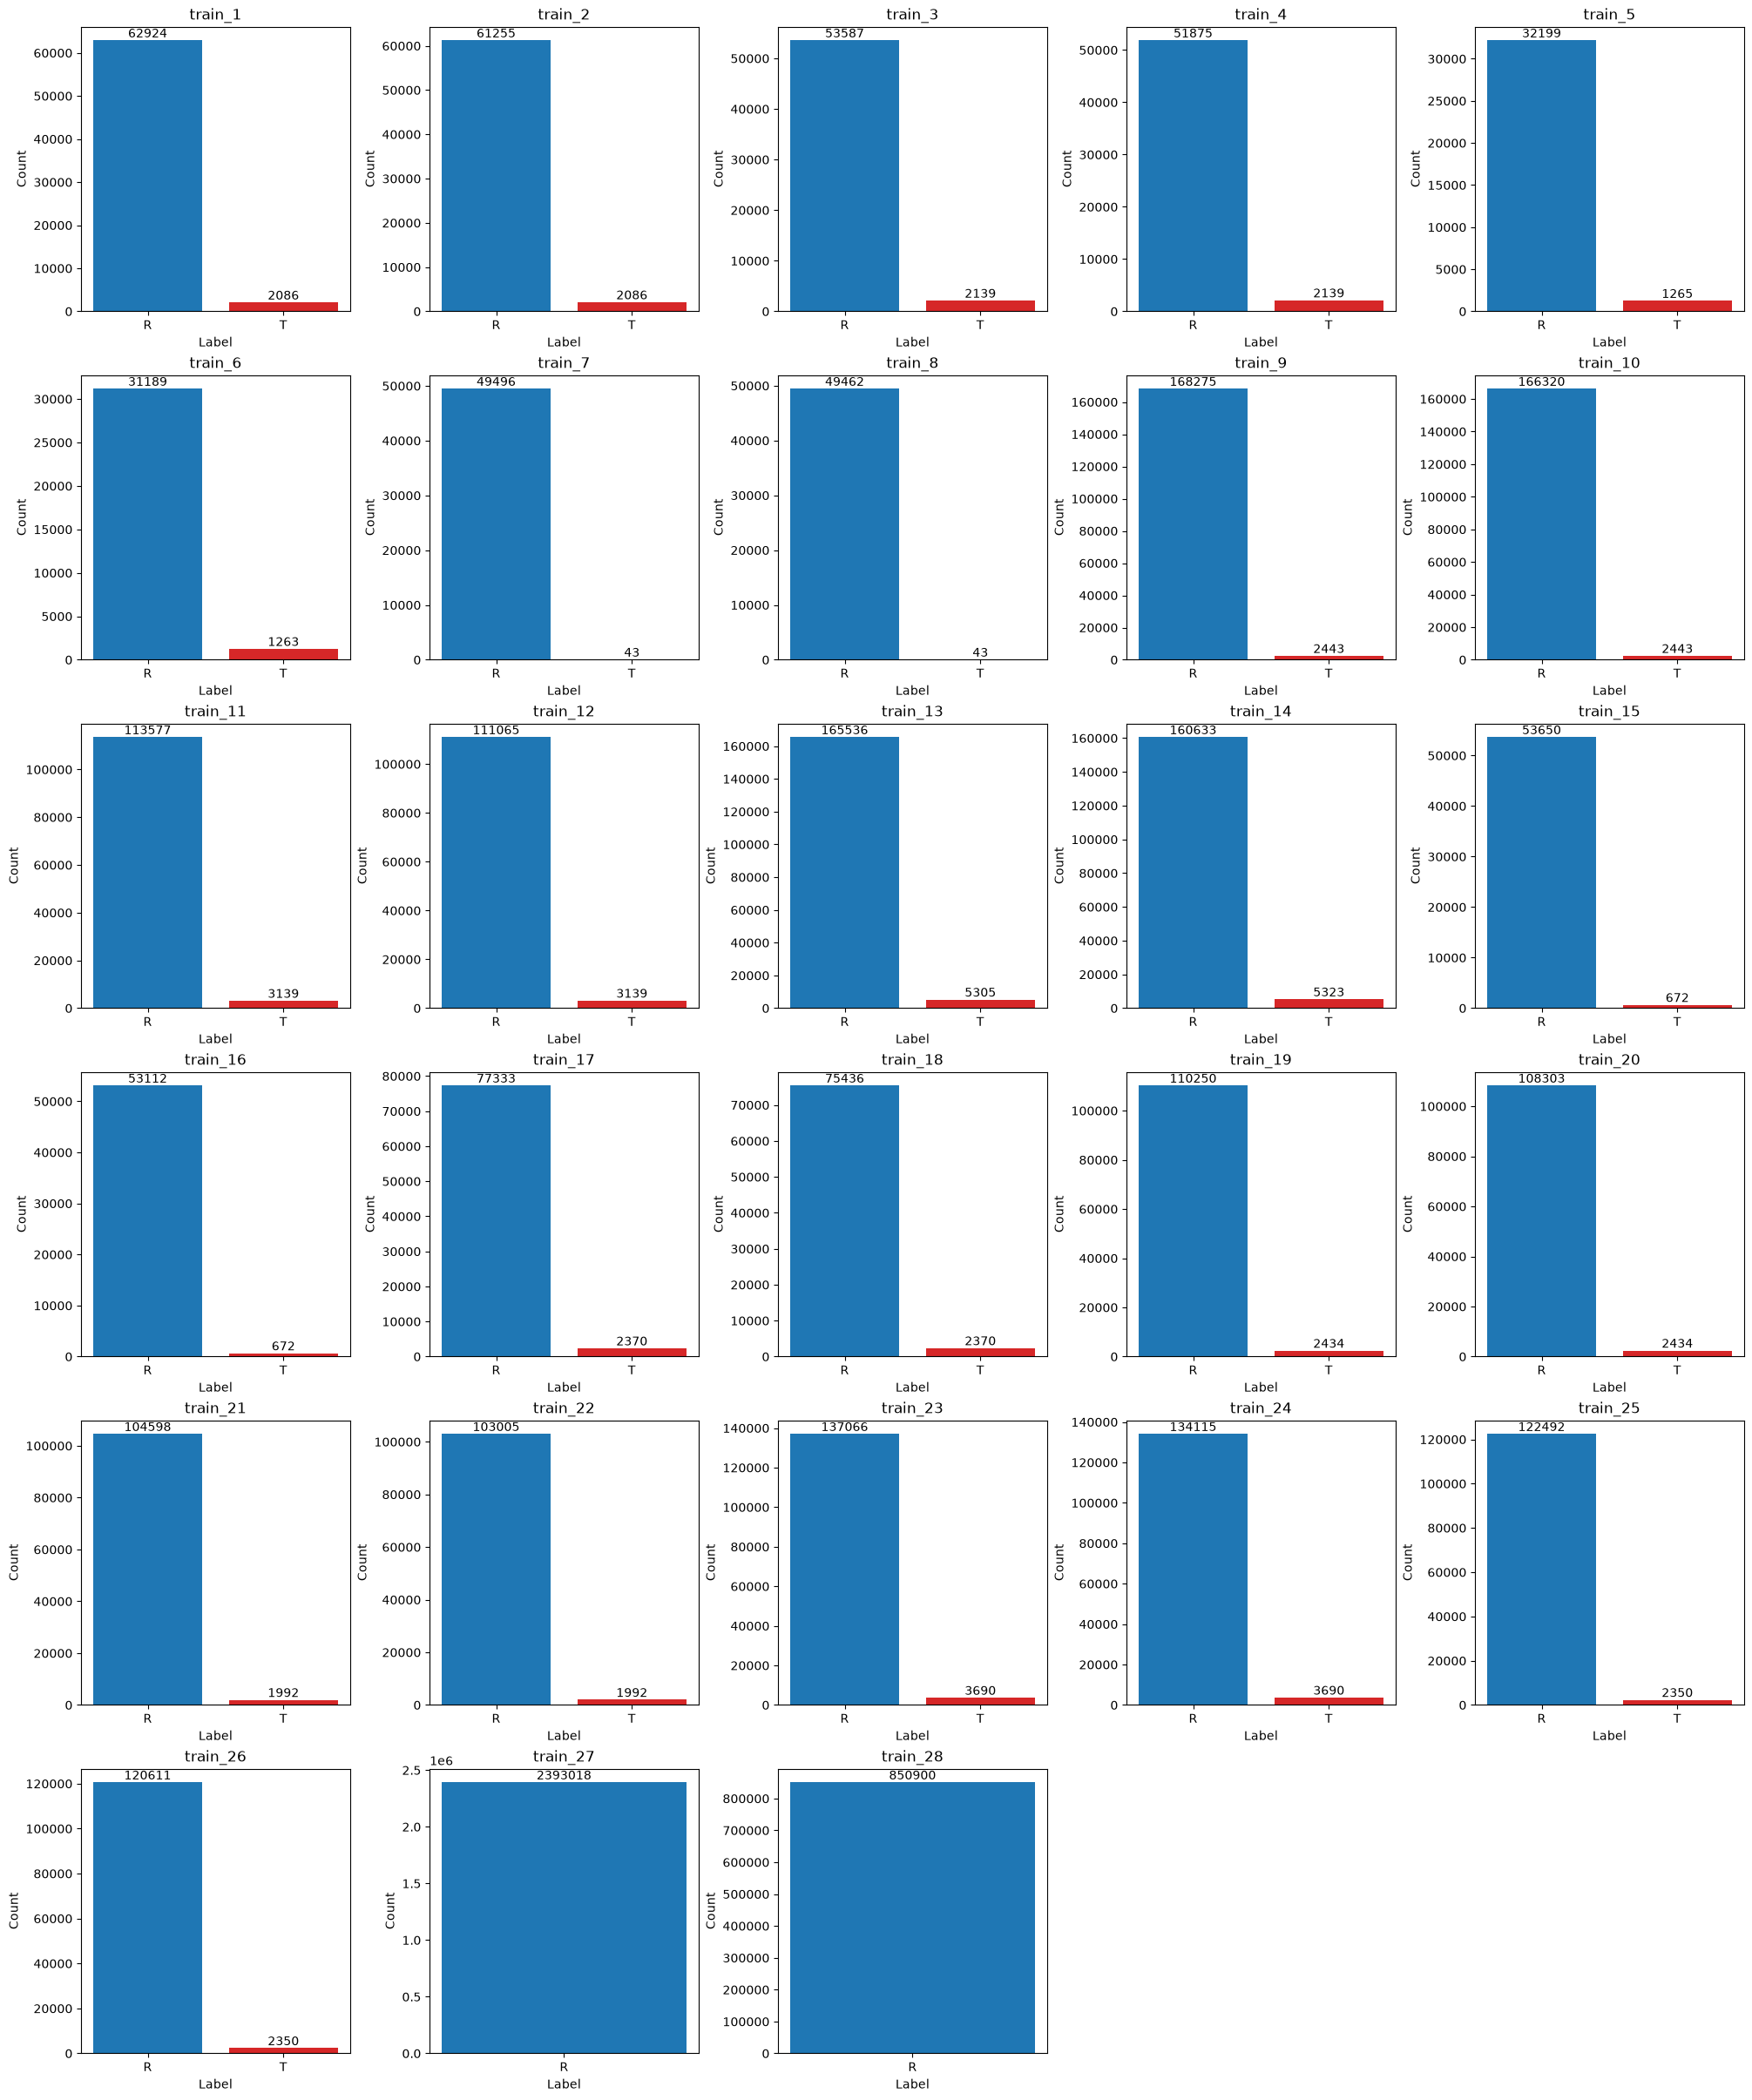

In [37]:
import numpy as np
import matplotlib.pyplot as plt

labels_by_dataset = {
    f"train_{i+1}": labels
    for i, labels in enumerate(attack_labels)
}

n = len(labels_by_dataset)
cols = 5
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), constrained_layout=True)
axes = axes.flatten()

for ax, (name, labels) in zip(axes, labels_by_dataset.items()):
    values, counts = np.unique(labels, return_counts=True)
    colors = ['tab:blue' if v == 'R' else 'tab:red' for v in values]
    ax.bar(values, counts, color=colors)
    ax.set_title(name)
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")
    for i, c in enumerate(counts):
        ax.text(i, c, str(c), ha="center", va="bottom")

for ax in axes[n:]:
    ax.axis("off")

plt.show()

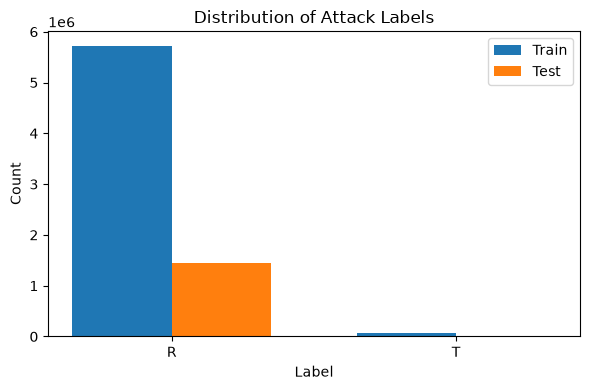

Training counts: Counter({'R': 5721282, 'T': 59872})
Test counts: Counter({'R': 1443689, 'T': 1586})


In [38]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Flatten list of arrays into a single array
train_labels = np.concatenate(attack_labels)
test_labels = np.concatenate(attack_labels_test)

# Count labels
train_counts = Counter(train_labels)
test_counts = Counter(test_labels)

labels = ['R', 'T']
train_values = [train_counts.get(label, 0) for label in labels]
test_values = [test_counts.get(label, 0) for label in labels]

# Plot
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, train_values, width, label='Train')
plt.bar(x + width/2, test_values, width, label='Test')

plt.xticks(x, labels)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Distribution of Attack Labels")
plt.legend()
plt.tight_layout()
plt.show()

print("Training counts:", train_counts)
print("Test counts:", test_counts)